In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from WBUtiles.WBClean import clean_wb_wide
from WBUtiles.WBSummary import summary_wb, plot_missing_heatmap
from WBUtiles.WBLatex import make_lookup_latex, make_summary_latex

sns.set_theme(
    style="whitegrid",     # clean academic look
    context="paper",       # scales text for papers
    font_scale=1.1
)

# Data Cleaning

In [2]:
geo = pd.read_csv('../data/Zambia_Geographic/geo_natural_resource.csv')

In [3]:
geo_clean, geo_lookup = clean_wb_wide(geo, drop_top_rows=0)

In [4]:
print(
    make_lookup_latex(
        geo_lookup,
        caption='World Bank indicators used in Geographic and Natural Resource Analysis',
        label='tab:geo_indicator_list'
    )
)

\begin{table}
\caption{World Bank indicators used in Geographic and Natural Resource Analysis}
\label{tab:geo_indicator_list}
\begin{tabular}{lp{10cm}}
\toprule
Series Code & Series Name \\
\midrule
AG.LND.IRIG.AG.ZS & Agricultural irrigated land (\% of total agricultural land) \\
AG.LND.AGRI.ZS & Agricultural land (\% of land area) \\
ER.H2O.FWTL.ZS & Annual freshwater withdrawals, total (\% of internal resources) \\
AG.LND.ARBL.ZS & Arable land (\% of land area) \\
NY.GDP.COAL.RT.ZS & Coal rents (\% of GDP) \\
EN.CLC.MDAT.ZS & Droughts, floods, extreme temperatures (\% of population, average 1990-2009) \\
AG.LND.FRST.ZS & Forest area (\% of land area) \\
NY.GDP.FRST.RT.ZS & Forest rents (\% of GDP) \\
VC.IDP.NWDS & Internally displaced persons, new displacement associated with disasters (number of cases) \\
ER.H2O.FWST.ZS & Level of water stress: freshwater withdrawal as a proportion of available freshwater resources \\
NY.GDP.MINR.RT.ZS & Mineral rents (\% of GDP) \\
NY.GDP.NGAS.RT.

# Check data availability

In [5]:
geo_summary = summary_wb(geo_clean, geo_lookup)
geo_summary

,Series Code,Series Name,missing_pct,n_obs,first_year,last_year
0,AG.LND.IRIG.AG.ZS,Agricultural irrigated land (% of total agricu...,100.000000,0,NaN,NaN
1,AG.LND.AGRI.ZS,Agricultural land (% of land area),3.076923,63,1961.0,2023.0
2,ER.H2O.FWTL.ZS,"Annual freshwater withdrawals, total (% of int...",52.307692,31,1992.0,2022.0
3,AG.LND.ARBL.ZS,Arable land (% of land area),3.076923,63,1961.0,2023.0
4,NY.GDP.COAL.RT.ZS,Coal rents (% of GDP),21.538462,51,1971.0,2021.0
5,EN.CLC.MDAT.ZS,"Droughts, floods, extreme temperatures (% of p...",98.461538,1,2009.0,2009.0
6,AG.LND.FRST.ZS,Forest area (% of land area),47.692308,34,1990.0,2023.0
7,NY.GDP.FRST.RT.ZS,Forest rents (% of GDP),20.000000,52,1970.0,2021.0
8,VC.IDP.NWDS,"Internally displaced persons, new displacement...",80.000000,13,2008.0,2023.0
9,ER.H2O.FWST.ZS,Level of water stress: freshwater withdrawal a...,52.307692,31,1992.0,2022.0


In [6]:
print(
    make_summary_latex(
    geo_summary,
    caption='Data availability of Geographic and Natural Resource Analysis (Zambia)',
    label='tab:geo_data_availability')
)

\begin{table}
\caption{Data availability of Geographic and Natural Resource Analysis (Zambia)}
\label{tab:geo_data_availability}
\begin{tabular}{lrrrr}
\toprule
Series Code & Missing (\textbackslash \%) & Obs. & First year & Last year \\
\midrule
AG.LND.IRIG.AG.ZS & 100.00 & 0 & NaN & NaN \\
AG.LND.AGRI.ZS & 3.10 & 63 & 1961.00 & 2023.00 \\
ER.H2O.FWTL.ZS & 52.30 & 31 & 1992.00 & 2022.00 \\
AG.LND.ARBL.ZS & 3.10 & 63 & 1961.00 & 2023.00 \\
NY.GDP.COAL.RT.ZS & 21.50 & 51 & 1971.00 & 2021.00 \\
EN.CLC.MDAT.ZS & 98.50 & 1 & 2009.00 & 2009.00 \\
AG.LND.FRST.ZS & 47.70 & 34 & 1990.00 & 2023.00 \\
NY.GDP.FRST.RT.ZS & 20.00 & 52 & 1970.00 & 2021.00 \\
VC.IDP.NWDS & 80.00 & 13 & 2008.00 & 2023.00 \\
ER.H2O.FWST.ZS & 52.30 & 31 & 1992.00 & 2022.00 \\
NY.GDP.MINR.RT.ZS & 20.00 & 52 & 1970.00 & 2021.00 \\
NY.GDP.NGAS.RT.ZS & 21.50 & 51 & 1971.00 & 2021.00 \\
NY.GDP.PETR.RT.ZS & 21.50 & 51 & 1971.00 & 2021.00 \\
ER.H2O.INTR.PC & 4.60 & 62 & 1961.00 & 2022.00 \\
ER.H2O.INTR.K3 & 4.60 & 62 & 1961.00

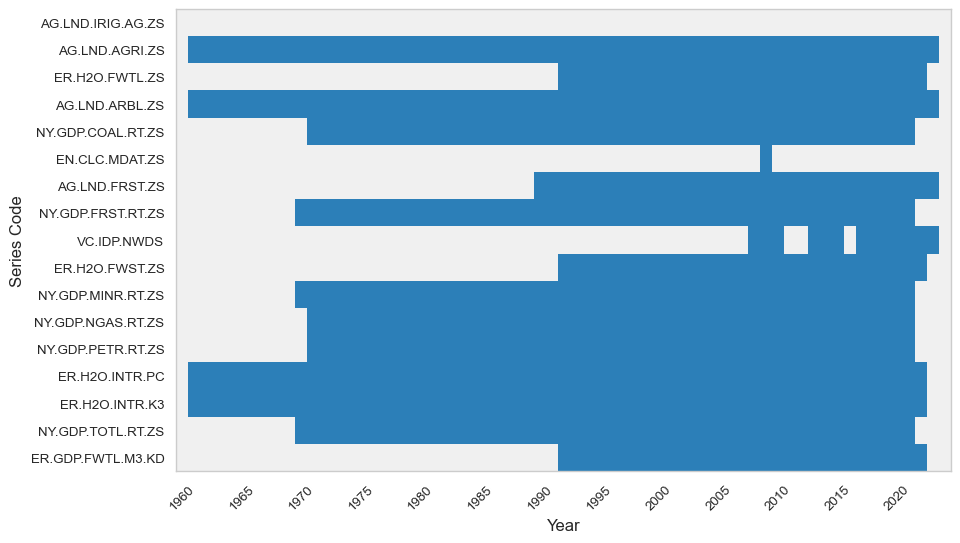

In [7]:
availability, fig, ax = plot_missing_heatmap(
    geo_clean,
    lookup=geo_lookup
)

fig.savefig('../figures/Zambia/geographic/geo_data_availability.png', bbox_inches='tight')

# Data Visualization

In [8]:
geo_lookup

,Series Code,Series Name
0,AG.LND.IRIG.AG.ZS,Agricultural irrigated land (% of total agricu...
1,AG.LND.AGRI.ZS,Agricultural land (% of land area)
2,ER.H2O.FWTL.ZS,"Annual freshwater withdrawals, total (% of int..."
3,AG.LND.ARBL.ZS,Arable land (% of land area)
4,NY.GDP.COAL.RT.ZS,Coal rents (% of GDP)
5,EN.CLC.MDAT.ZS,"Droughts, floods, extreme temperatures (% of p..."
6,AG.LND.FRST.ZS,Forest area (% of land area)
7,NY.GDP.FRST.RT.ZS,Forest rents (% of GDP)
8,VC.IDP.NWDS,"Internally displaced persons, new displacement..."
9,ER.H2O.FWST.ZS,Level of water stress: freshwater withdrawal a...


## Geographic and Climate Measures

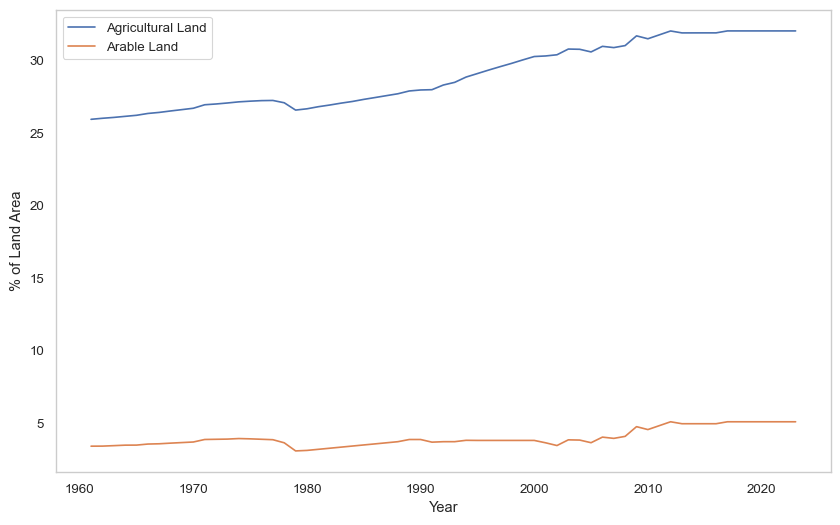

In [19]:
# percentage of arable land
df = geo_clean.dropna(subset=['AG.LND.AGRI.ZS','AG.LND.ARBL.ZS'])
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df['Year'], df['AG.LND.AGRI.ZS'], label= 'Agricultural Land')
ax.plot(df['Year'], df['AG.LND.ARBL.ZS'], label= 'Arable Land')

ax.set_xlabel('Year')
ax.set_ylabel('% of Land Area')
ax.legend()
ax.grid(False)

In [22]:
# Show range, average, and std of arable land and agricultural land by statistic table
df = geo_clean.dropna(subset=['AG.LND.AGRI.ZS','AG.LND.ARBL.ZS'])
df[['AG.LND.AGRI.ZS','AG.LND.ARBL.ZS']].describe()

print(
    make_summary_latex(
    df[['AG.LND.AGRI.ZS','AG.LND.ARBL.ZS']].describe().T,
    caption='Summary statistics of Agricultural Land and Arable Land (% of land area)',
    label='tab:land_summary')
)

\begin{table}
\caption{Summary statistics of Agricultural Land and Arable Land (% of land area)}
\label{tab:land_summary}
\begin{tabular}{rrrrrrrr}
\toprule
count & mean & std & min & 25\% & 50\% & 75\% & max \\
\midrule
63.00 & 28.97 & 2.20 & 25.97 & 27.06 & 28.34 & 31.03 & 32.07 \\
63.00 & 4.00 & 0.60 & 3.10 & 3.62 & 3.83 & 4.08 & 5.11 \\
\bottomrule
\end{tabular}
\end{table}



In [27]:
# data on climate such as temperature, rainfall etc (long-term averages)
df = geo_clean.dropna(subset = ['EN.CLC.MDAT.ZS'])
df['EN.CLC.MDAT.ZS'] # Droughts, floods, extreme temperatures (% of population, average 1990-2009)

49    4.199677
Name: EN.CLC.MDAT.ZS, dtype: float64

Check more temperature and rainfall data on:
https://climateknowledgeportal.worldbank.org/country/zambia/climate-data-historical

In [ ]:
# Observed Seasonal Cycle

## Natural Resource Measures

In [ ]:
# oil rents as % of GDP


In [ ]:
# natural gas rents as % of GDP